# 0. Section: Mount Drive for Data Acess
Acess all the necessary documents and prepare the working env

In [16]:
import os
from google.colab import drive

print("🚀 Initializing Colab Environment...")

# 1. Mount Google Drive (This will pop up a permission window)
drive.mount('/content/drive')

# 2. Define your project workspace path
# (Change 'MRI_ResUNet_Project' to whatever you named the folder in your Drive)
PROJECT_PATH = '/content/drive/MyDrive/ResUNet_Project'

# 3. Automate folder creation (If it doesn't exist, build it)
os.makedirs(PROJECT_PATH, exist_ok=True)

# 4. Change the working directory
os.chdir(PROJECT_PATH)
print(f"✅ Working Directory Set To: {os.getcwd()}")

# 5. Verify the files are there
print("\n📁 Files currently in your project folder:")
print(os.listdir())

🚀 Initializing Colab Environment...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Working Directory Set To: /content/drive/MyDrive/ResUNet_Project

📁 Files currently in your project folder:
['Group 9', 'visualize.py', 'Inference.py', 'U_net.py', '__pycache__', 'Data_prep.py', 'X_data_xray.npy', 'MRI_Plots.png', 'y_data_mri.npy', 'y_data_xray.npy', 'Xray_Plots.png', 'X_data_mri.npy', 'Imaging_Notebook.ipynb', 'Outputs']


# 1. Section: Import Required Libraries
Import all necessary packages including OpenCV, NumPy, Matplotlib, PyTorch, segmentation_models_pytorch, and scikit-learn.

In [17]:
import os
from glob import glob
import cv2
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torchvision.models as models
!pip install segmentation_models_pytorch
import segmentation_models_pytorch as smp

# 2. Section: Define Configuration Parameters
Define the `Config` class to store hyperparameters, architecture settings like 'resnet34', batch sizes, and plotting functions.

In [18]:
class Config:
    # Architecture
    encoder_name = 'resnet34'
    encoder_weights = 'imagenet'
    pretrained = True
    in_channels = 3
    classes = 1

    # Training
    batch_size = 4
    learning_rate = 1e-4
    epochs = 200
    train_test_ratio = 0.4

    @classmethod
    def plotting_loss(cls, train_losses, val_losses):
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, cls.epochs + 1), train_losses, label='Training Loss (MAE)', color='blue')
        plt.plot(range(1, cls.epochs + 1), val_losses, label='Validation Loss (MAE)', color='red', linestyle='--')

        plt.title('ResUNet MRI Reconstruction Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.savefig('Outputs/training_validation_loss.png')
        plt.show()

# 3. Section: Implement Data Handling and Filtering
Create the `Data_Handler` class containing the logic to apply Canny, Sobel, and Laplacian filters, normalize images, stack channels, and implement the plotting grid method.

In [19]:
class Data_Handler:
    def __init__(self, path, size=(256, 256)):
        self.path = path
        self.size = size

    def Data_prep(self):
        images_mri = []
        filter_3_mri = []
        images_xray = []
        filter_3_xray = []

        for folder_path in self.path:
            if "MRI" in folder_path:
                search_pattern = os.path.join(folder_path, "*.*")
                for file_path in sorted(glob(search_pattern)):
                    if not file_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue
                    img = cv2.imread(file_path)
                    img = cv2.resize(img, self.size)
                    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                    img = img / 255.0

                    images_mri.append(img)

                    f1_normalised = cv2.Canny((img*255).astype(np.uint8), 100, 200) / 255.0
                    f2 = cv2.Sobel((img*255).astype(np.uint8), cv2.CV_64F, 1, 0, ksize=5)
                    f2_normalised = (f2 - np.min(f2)) / (np.max(f2) - np.min(f2) + 1e-8)
                    f3 = cv2.Laplacian((img*255).astype(np.uint8), cv2.CV_64F)
                    f3_normalised = (f3 - np.min(f3)) / (np.max(f3) - np.min(f3) + 1e-8)

                    list_3 = [f1_normalised, f2_normalised, f3_normalised]
                    combined_filters = np.stack(list_3, axis=-1)
                    filter_3_mri.append(combined_filters)

            if "Xray" in folder_path:
                search_pattern = os.path.join(folder_path, "*.*")
                for file_path in sorted(glob(search_pattern)):
                    if not file_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue
                    img = cv2.imread(file_path)
                    img = cv2.resize(img, self.size)
                    img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                    img = img / 255.0

                    images_xray.append(img)

                    f1_normalised = cv2.Canny((img*255).astype(np.uint8), 100, 200) / 255.0
                    f2 = cv2.Sobel((img*255).astype(np.uint8), cv2.CV_64F, 1, 0, ksize=5)
                    f2_normalised = (f2 - np.min(f2)) / (np.max(f2) - np.min(f2) + 1e-8)
                    f3 = cv2.Laplacian((img*255).astype(np.uint8), cv2.CV_64F)
                    f3_normalised = (f3 - np.min(f3)) / (np.max(f3) - np.min(f3) + 1e-8)

                    list_3 = [f1_normalised, f2_normalised, f3_normalised]
                    combined_filters = np.stack(list_3, axis=-1)
                    filter_3_xray.append(combined_filters)

        # Make directories if they do not exist
        os.makedirs("Outputs", exist_ok=True)

        X_mri = np.array(filter_3_mri)
        y_mri = np.array(images_mri)
        np.save("Outputs/X_data_mri.npy", X_mri)
        np.save("Outputs/y_data_mri.npy", y_mri)

        X_xray = np.array(filter_3_xray)
        y_xray = np.array(images_xray)
        np.save("Outputs/X_data_xray.npy", X_xray)
        np.save("Outputs/y_data_xray.npy", y_xray)

        return X_mri, y_mri, X_xray, y_xray

    @staticmethod
    def plot_grid(X, y, type="MRI", predictions=None):
        type = type.upper()
        num_rows = X.shape[0]

        if type not in ["MRI", "XRAY", "PREDICT"]:
            type = "GRID"

        if type == "PREDICT" and predictions is not None:
            predictions = predictions[:num_rows]

        num_cols = 5 if (type == "PREDICT" and predictions is not None) else 4
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 3))

        if num_rows == 1:
            axes = [axes]

        for i in range(num_rows):
            filters_img = X[i]
            original_img = y[i]

            axes[i][0].imshow(original_img, cmap='gray')
            axes[i][0].set_xticks([])
            axes[i][0].set_yticks([])

            axes[i][1].imshow(filters_img[:, :, 0], cmap='gray')
            axes[i][1].set_xticks([])
            axes[i][1].set_yticks([])

            axes[i][2].imshow(filters_img[:, :, 1], cmap='gray')
            axes[i][2].set_xticks([])
            axes[i][2].set_yticks([])

            axes[i][3].imshow(filters_img[:, :, 2], cmap='gray')
            axes[i][3].set_xticks([])
            axes[i][3].set_yticks([])

            if type == "PREDICT" and predictions is not None:
                axes[i][4].imshow(predictions[i, :, :, 0], cmap='gray')
                axes[i][4].set_xticks([])
                axes[i][4].set_yticks([])

        plt.show()

# 4. Section: Execute Data Preparation Pipeline
Instantiate the `Data_Handler` passing the target directories, execute the data preparation to generate filter stacks, and save the resulting numpy arrays to disk.

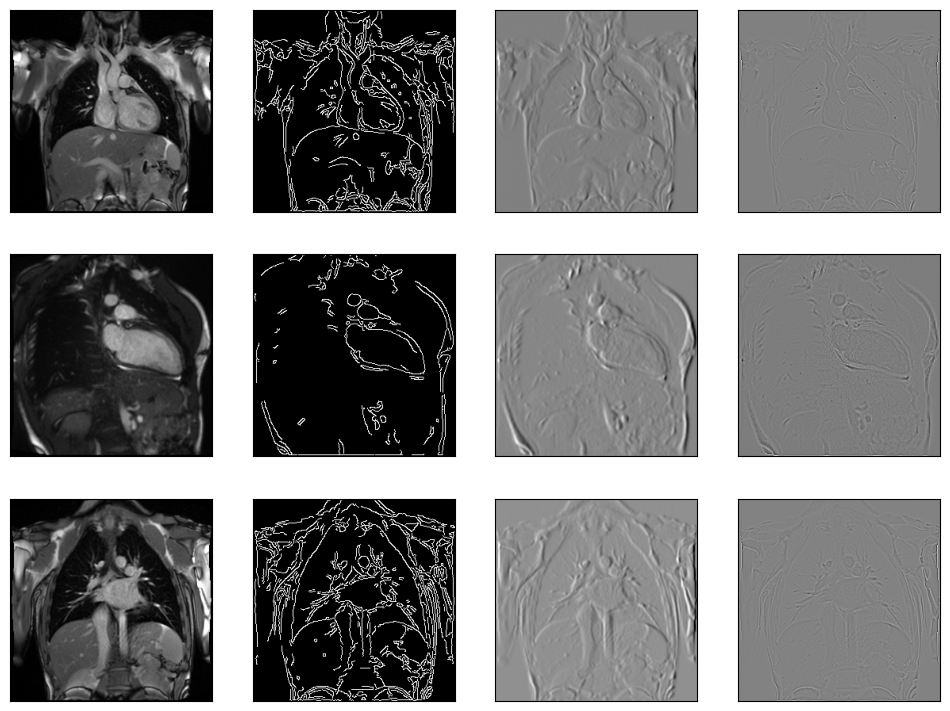

In [20]:
path = [r"/content/drive/MyDrive/ResUNet_Project/Group 9/MRI",
        r"/content/drive/MyDrive/ResUNet_Project/Group 9/Xray"]

X_mri, y_mri, X_xray, y_xray = Data_Handler(path).Data_prep()
Data_Handler.plot_grid(X=X_mri[:3], y=y_mri[:3], type="MRI")

# 5. Section: Create PyTorch Dataset Custom Class
Define the `scan_Dataset` class inheriting from `torch.utils.data.Dataset` to convert the numpy arrays into appropriate PyTorch tensors with correct channel dimensions.

In [21]:
class scan_Dataset(Dataset):
    def __init__(self, X_data, y_data):
        self.x = X_data
        self.y = y_data

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, index):
        img = self.x[index]
        label = self.y[index]

        img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1)
        label_tensor = torch.tensor(label, dtype=torch.float32).unsqueeze(0)

        return img_tensor, label_tensor

# 6. Section: Build ResUnet Model and Training Loop
Implement the `model_build` class to initialize the segmentation model, configure the Adam optimizer and L1 Loss, and construct the standard training and validation epochs loop.

In [22]:
class model_build:
    def __init__(self):
        self.model = smp.Unet(
            encoder_name=Config.encoder_name,
            encoder_weights=Config.encoder_weights,
            in_channels=Config.in_channels,
            classes=Config.classes,
        )
    def compile(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self.model.to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=Config.learning_rate)
        self.criterion = torch.nn.L1Loss()

    def train(self, train_loader, val_loader):
        train_losses = []
        val_losses = []
        for epoch in range(Config.epochs):
            self.model.train()
            train_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                train_loss += loss.item() * images.size(0)

            avg_train_loss = train_loss / len(train_loader.dataset)

            self.model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
                    val_loss += loss.item() * images.size(0)

            avg_val_loss = val_loss / len(val_loader.dataset)

            print(f'Epoch [{epoch+1}/{Config.epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

            train_losses.append(avg_train_loss)
            val_losses.append(avg_val_loss)

        torch.save(self.model.state_dict(), f"Outputs/{Config.encoder_name}_model.pth")
        return train_losses, val_losses

# 7. Section: Prepare Data Loaders and Train the Model
Load the `.npy` files, split them using `train_test_split`, initialize PyTorch `DataLoader` instances, and execute the training process, followed by plotting the learning curves.

Epoch [1/200], Train Loss: 1.0754, Val Loss: 0.4499
Epoch [2/200], Train Loss: 0.9990, Val Loss: 0.7691
Epoch [3/200], Train Loss: 0.9375, Val Loss: 0.8554
Epoch [4/200], Train Loss: 0.7734, Val Loss: 0.8011
Epoch [5/200], Train Loss: 0.6882, Val Loss: 0.6755
Epoch [6/200], Train Loss: 0.6034, Val Loss: 0.5248
Epoch [7/200], Train Loss: 0.4905, Val Loss: 0.4023
Epoch [8/200], Train Loss: 0.4561, Val Loss: 0.3280
Epoch [9/200], Train Loss: 0.4951, Val Loss: 0.3064
Epoch [10/200], Train Loss: 0.3409, Val Loss: 0.2570
Epoch [11/200], Train Loss: 0.3179, Val Loss: 0.2254
Epoch [12/200], Train Loss: 0.3500, Val Loss: 0.2021
Epoch [13/200], Train Loss: 0.3169, Val Loss: 0.1832
Epoch [14/200], Train Loss: 0.2511, Val Loss: 0.1690
Epoch [15/200], Train Loss: 0.2532, Val Loss: 0.1580
Epoch [16/200], Train Loss: 0.2151, Val Loss: 0.1496
Epoch [17/200], Train Loss: 0.1998, Val Loss: 0.1438
Epoch [18/200], Train Loss: 0.1929, Val Loss: 0.1402
Epoch [19/200], Train Loss: 0.1937, Val Loss: 0.1373
Ep

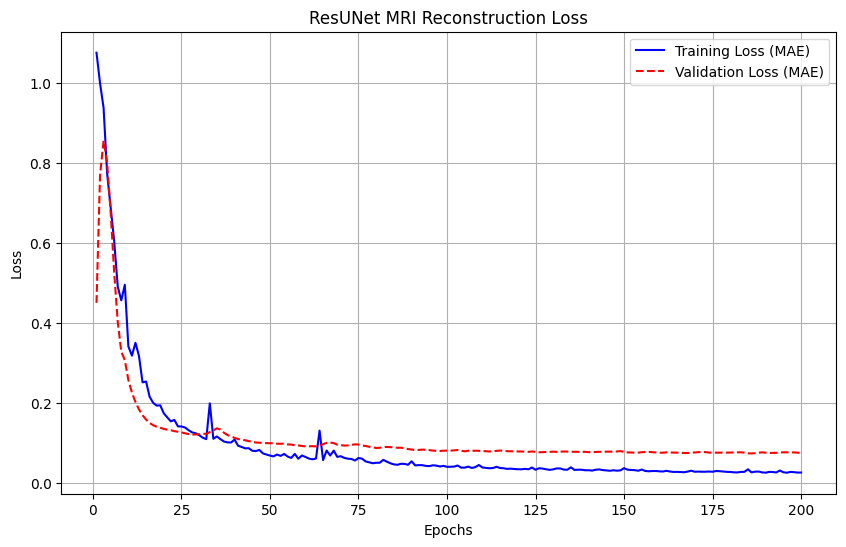

In [23]:
X = np.load("Outputs/X_data_mri.npy")
y = np.load("Outputs/y_data_mri.npy")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=Config.train_test_ratio)

train_dataset = scan_Dataset(X_train, y_train)
val_dataset = scan_Dataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.batch_size, shuffle=False)

model = model_build()
model.compile()
train_losses, val_losses = model.train(train_loader, val_loader)

Config.plotting_loss(train_losses, val_losses)

# 8. Section: Define Inference Architecture
Create the `inf_model` class to load the saved `.pth` model weights and establish a `predict` method that handles tensor permutations for model evaluation.

In [24]:
class inf_model:
    def __init__(self):
        self.model = smp.Unet(
            encoder_name=Config.encoder_name,
            encoder_weights=Config.encoder_weights,
            in_channels=Config.in_channels,
            classes=Config.classes
        )
        self.device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
        self.model.to(self.device)

    def load_weights(self, path):
        self.model.load_state_dict(torch.load(path))
        self.model.eval()

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.from_numpy(X).float().permute(0, 3, 1, 2).to(self.device)
            predictions = self.model(X_tensor)
            return predictions.cpu().permute(0, 2, 3, 1).numpy()

# 9. Section: Run Predictions and Visualize Results
Initialize the inference class, load a subset of the validation data, generate predictions, and utilize the plotting utility to compare original MRI images, filtered inputs, and ResUNet outputs side-by-side.

Test Validation shape: (3, 256, 256, 3), X_val Shape: (4, 256, 256, 3)


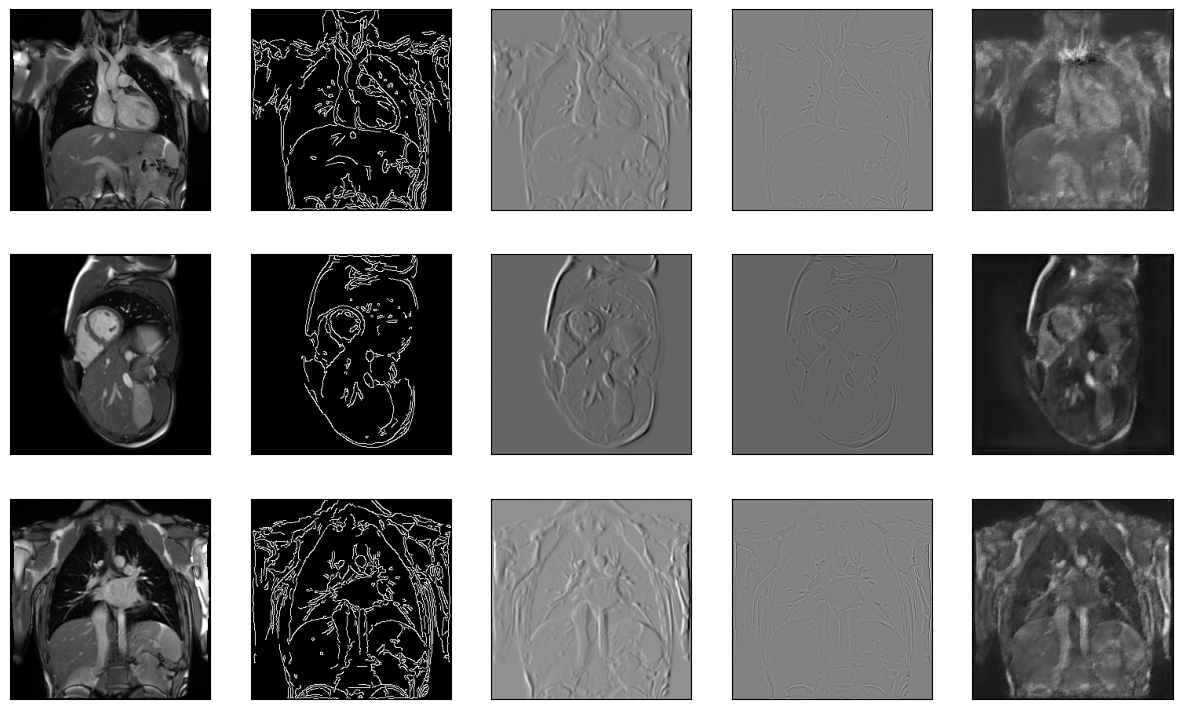

In [25]:
inf = inf_model()
inf.load_weights(f"Outputs/{Config.encoder_name}_model.pth")

test_val = X_val[:3]
predictions = inf.predict(test_val)

print(f"Test Validation shape: {test_val.shape}, X_val Shape: {X_val.shape}")

Data_Handler.plot_grid(X=test_val, y=y_val[:3], type="PREDICT", predictions=predictions)